**VERSION v5**: Uses new signal and satellite catalog.

Tipos de gráficos a fazer:
- Gráfico que mostra as potências integradas sobre todo o mapa freq x time, para ver os sinais com maior contribuição.
- Fazer uma plot dos satélites de potência integrada do beam_response vs. potência integrada da simulação final - satélites com elevada potência final mas baixa potência inicial devem ser maus fit aos dados.
- Ver que sinais têm a maior potência integrada = vão contribuir mais para a imagem final, e observar o imshow desses sinais.

Fazer tudo isto para a nova lista e a velha também (para ver se alguns sinais que antes eram importantes agora não aparecem, e se desapareceram por um bom motivo ou se de facto posso me ter enganado nas listas).

## 1. Initialization

Imports and general parameters (from *parameters.py*).

In [28]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation_NC as sim
import natsort
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm
from matplotlib.ticker import LogLocator, FormatStrFormatter


In [30]:
## ----- FITTING PARAMETERS ----- ##

# folder and name of final results file
folder = "results/v5_results/"

# cost function from eq. 11 (options: "C1"=radiometer, "C2"=1)
CF = "C1"

# angular mask [degrees] (options: "1F","5F" or None)
deg = None
if deg==None:  path_nearby = None
else:  path_nearby = (pm.path_data+"nearby_satellites/nearby_satellite_close_angle_"+deg+".p")

# thermal mask [kelvin] (options: 25,50,100 or None)
temp = None

# threshold pixel mask (options: 2,5,7 or None)
pix = None

# temporal mask [seconds] (options: 775-1000, 2200-2400, 5500-6200 or None)
time_slice = (None,None)


In [31]:
pm.show_parameters(CF, deg, temp, pix, time_slice)
print("")
print(f"Showing results from folder: {folder}")


Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: inf - inf seconds
The cost function denominator will be: radiometer equation (C1).
Masking: None

Showing results from folder: results/v5_results/


## 2. Set-up of global variables and functions

We start by initializing the simulation, and also the satellite listing that has additional information (such as the constellation, generation and name of a given satellite).

Getting catalog...
 - Number of signals in satellite catalog: 292 (initial), 155 (final).
Getting beam response...
 - Number of satellites present: 73
 - Size of sat_beam: 1.437 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 155
 - Size of Tb_factors: 0.001 GB
Starting index of satellites:  [  0   4   8  12  16  20  21  22  23  24  26  30  32  33  34  35  38  41
  44  47  50  53  56  59  62  65  68  71  74  76  78  80  82  84  84  85
  86  86  86  87  88  88  89  92  94  96  98 100 102 105 107 109 111 113
 116 119 121 123 125 127 129 131 133 135 137 139 141 143 145 147 149 151
 153]
Getting observational data...
 - Size of observational data: 0.020 GB
 - Shape of observational data: (1199, 2204)


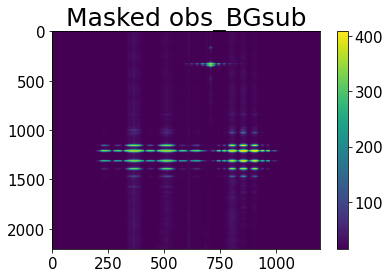

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (2204,)
 - Size of simulated Tb_factors:  (155, 1199)
 - Size of simulated sat_beam:  (73, 1199, 2204)
 - Size of observations:  (1199, 2204)


In [32]:
# initializing the simulation
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog=pm.path_catalog,
    path_beam=pm.path_beam,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=time_slice,
    verbose=True,
)

# getting observations and mask
sat.use_observations(path_observations=pm.path_observations, verbose=True)
sat.use_mask(path_nearby, temp, pix, verbose=True)

# define some quantities
frequency = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
time = sat.time[sat.itime[0]:sat.itime[1]]


In [33]:
# getting alpha best-fit values
print("Getting best-fit values...")
fname = pm.my_name(folder, CF, deg, temp, pix, time_slice)
alphas = pickle.load( open(fname,"rb") )["best-fit"]

# getting the simulation
print("Simulating...")
sat.simulate(alphas)


Getting best-fit values...
Simulating...


In [34]:
# getting satellite info
satellites = pd.read_csv("data/satellites.csv")
satellites = satellites.set_index("NORAD ID")

# getting signal info
#signals = pd.read_csv("data/signals.csv")
#signals = signals[signals["Frequency(MHz)"] >= pm.freq_slice[0]]
#signals = signals[signals["Frequency(MHz)"] <= pm.freq_slice[1]]


## 3. Graphs

We now define several different graphs that will check different properties of the best-fit simulation that was obtained. The first graphs represent the alphas obtained per signal (divided by constellation), the second graphs represent the power amplitude obtained per signal (includes P,G; divided by constellation), and the third graphs represent the simulated signal from each satellite compared to the total observations.

In [8]:
# ------------------ plot_alphas ------------------- #
def plot_alphas(con, log=False):
    ''' Plot alphas of each signal for a given constellation. '''

    # creating figure
    fig, ax = plt.subplots(figsize=(9, 5))
    linestyles = ["-", "--", "-.", ":"]
    nulls = []

    for i,ID in enumerate(sat.sats):
        # getting values
        if satellites.loc[ID,"Constellation"]!=con:  continue
        ys = alphas[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        xs = sat.catalog.loc[sat.catalog["NORAD ID"]==ID,"Signal"]
        name = satellites.loc[ID,"Satellite"]

        # if satellite has only null alphas, remove
        if np.abs(np.linalg.norm(ys))<1e-6:  
            nulls.append(name)
            continue

        #plotting the rest
        ys_plot = np.where(ys>0,ys,np.nan)
        if log:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)
        else:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=f"{name}")

        # plotting zero values
        idx0 = np.where(np.abs(ys)<1e-6)[0]
        if len(idx0):
            ax.plot(np.asarray(xs)[idx0], np.full(len(idx0), ax.get_ylim()[0]), "x",
                    color=ax.lines[-1].get_color(), ms=8)

    # showing figure
    if log:  
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_ylabel('Amplitude')
    ax.set_xlabel(r'Signal $[\alpha_{i}]$')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.set_title(f"Alphas for {con}")
    fig.tight_layout()
    plt.show()
    print(f"Satellites with only null alphas: {nulls}")
    

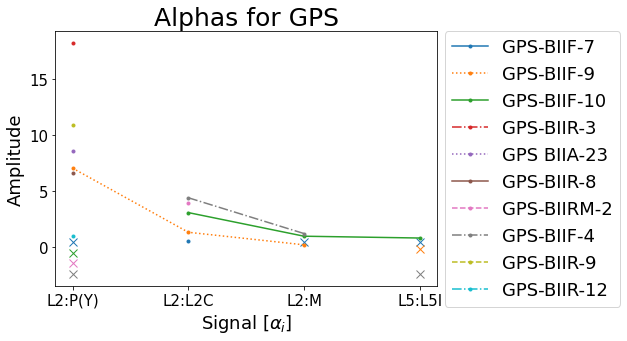

Satellites with only null alphas: ['GPS-BIIF-12', 'GPS-BIIF-8', 'GPS-BIIR-6', 'GPS-BIIRM-6', 'GPS-BIIR-10']


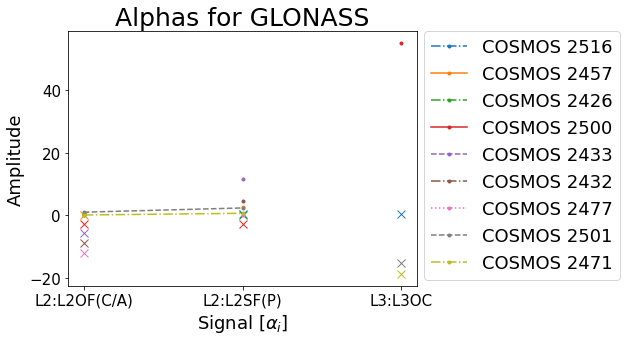

Satellites with only null alphas: ['COSMOS 2492', 'COSMOS 2475', 'COSMOS 2464', 'COSMOS 2456']


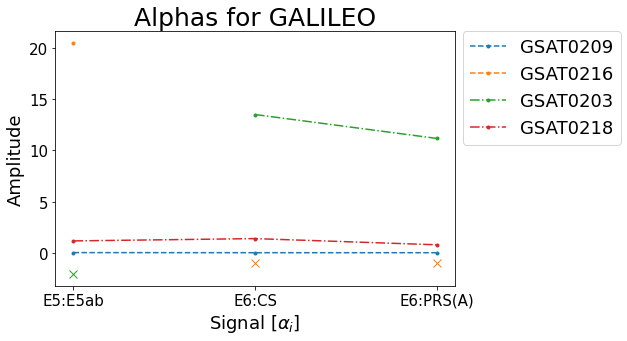

Satellites with only null alphas: ['GSAT0201', 'GSAT0205', 'GSAT0210', 'GSAT0222', 'GSAT0213', 'GSAT0214', 'GSAT0102', 'GSAT0212', 'GSAT0101']


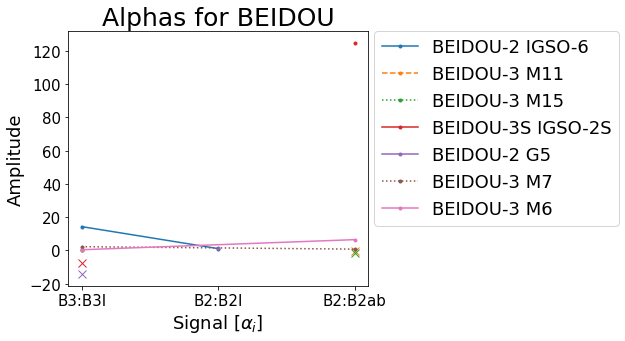

Satellites with only null alphas: ['BEIDOU-3S IGSO-1S', 'BEIDOU-2 IGSO-5', 'BEIDOU-2 M6', 'BEIDOU-2 IGSO-3', 'BEIDOU-2 M4', 'BEIDOU-3 M17', 'BEIDOU-3 M5', 'BEIDOU-3 M1', 'BEIDOU-2 G6', 'BEIDOU-2 G3', 'BEIDOU-3 M8']


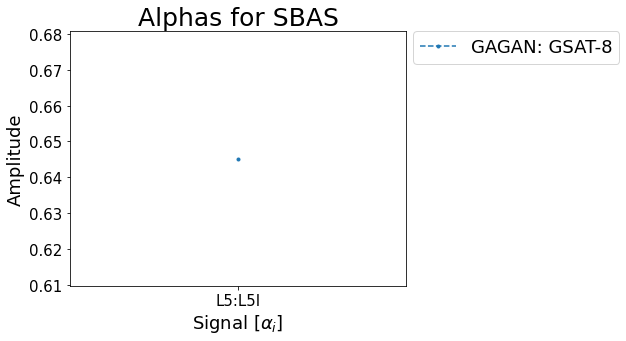

Satellites with only null alphas: ['EGNOS: Inmarsat-3 F2', 'EGNOS: Astra 5B', 'GAGAN: GSAT-15', 'SDCM: Luch-5V', 'EGNOS: Inmarsat-4 F2', 'EGNOS: SES-5', 'GAGAN: GSAT-10', 'SDCM: Luch-5B']


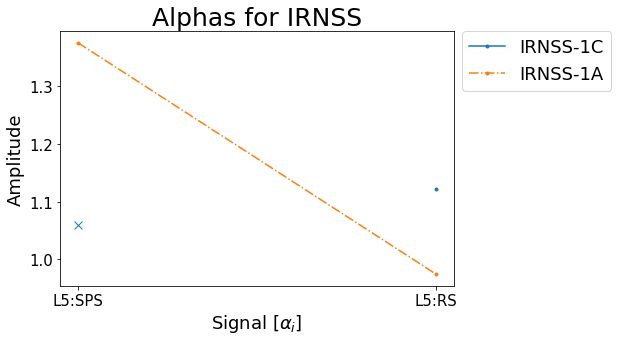

Satellites with only null alphas: ['IRNSS-1B', 'IRNSS-1I', 'IRNSS-1F']


In [9]:
cons = ["GPS","GLONASS","GALILEO","BEIDOU","SBAS","IRNSS"]
for con in cons:
    plot_alphas(con,log=False)


In [60]:
# ------------------ plot_power -------------------- #
def plot_power(con, log=False):
    ''' Plot alphas of each signal for a given constellation. '''

    # creating figure
    fig, ax = plt.subplots(figsize=(9, 5))
    linestyles = ["-", "--", "-.", ":"]
    nulls = []

    for i,ID in enumerate(sat.sats):
        # getting values
        if satellites.loc[ID,"Constellation"]!=con:  continue
        Ps = np.array(sat.catalog["P(dBW)"])[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        Gs = np.array(sat.catalog["G(dBi)"])[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        ys = alphas[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]] * 10**(Ps/10 + Gs/10)
        xs = sat.catalog.loc[sat.catalog["NORAD ID"]==ID,"Signal"]
        name = satellites.loc[ID,"Satellite"]

        # if satellite has only null alphas, remove
        if np.abs(np.linalg.norm(ys))<1e-6:  
            nulls.append(name)
            continue

        #plotting the rest
        ys_plot = np.where(ys>0,ys,np.nan)
        if log:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)
        else:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=f"{name}")

        # plotting zero values
        idx0 = np.where(np.abs(ys)<1e-6)[0]
        if len(idx0):
            ax.plot(np.asarray(xs)[idx0], np.full(len(idx0), ax.get_ylim()[0]), "x",
                    color=ax.lines[-1].get_color(), ms=8)

    # showing figure
    if log:  
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_ylabel(r'Power $[\alpha_{i} \times 10^{P/10 + G/10}]$')
    ax.set_xlabel(r'Signal $[\alpha_{i}]$')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.set_title(f"Power for {con}")
    fig.tight_layout()
    plt.show()
    print(f"Satellites with only null alphas: {nulls}")
    

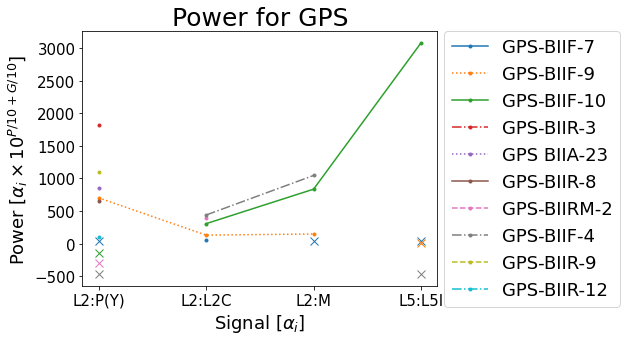

Satellites with only null alphas: ['GPS-BIIF-12', 'GPS-BIIF-8', 'GPS-BIIR-6', 'GPS-BIIRM-6', 'GPS-BIIR-10']


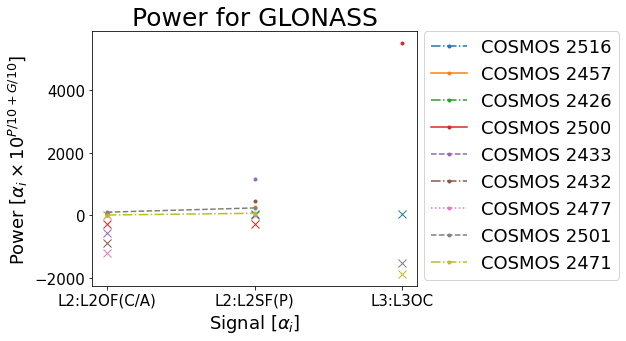

Satellites with only null alphas: ['COSMOS 2492', 'COSMOS 2475', 'COSMOS 2464', 'COSMOS 2456']


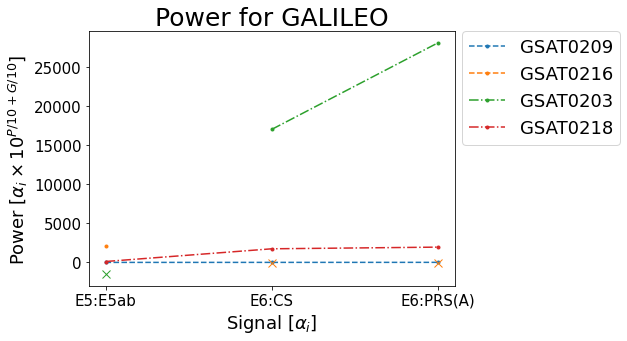

Satellites with only null alphas: ['GSAT0201', 'GSAT0205', 'GSAT0210', 'GSAT0222', 'GSAT0213', 'GSAT0214', 'GSAT0102', 'GSAT0212', 'GSAT0101']


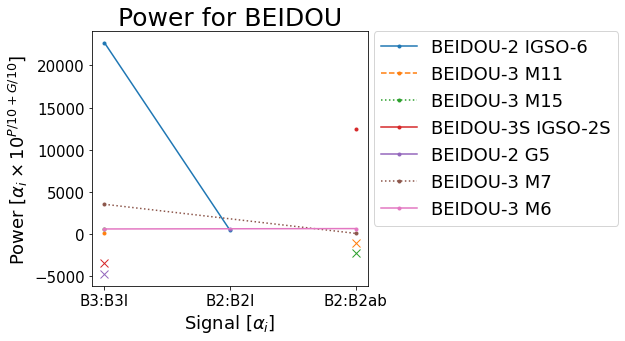

Satellites with only null alphas: ['BEIDOU-3S IGSO-1S', 'BEIDOU-2 IGSO-5', 'BEIDOU-2 M6', 'BEIDOU-2 IGSO-3', 'BEIDOU-2 M4', 'BEIDOU-3 M17', 'BEIDOU-3 M5', 'BEIDOU-3 M1', 'BEIDOU-2 G6', 'BEIDOU-2 G3', 'BEIDOU-3 M8']


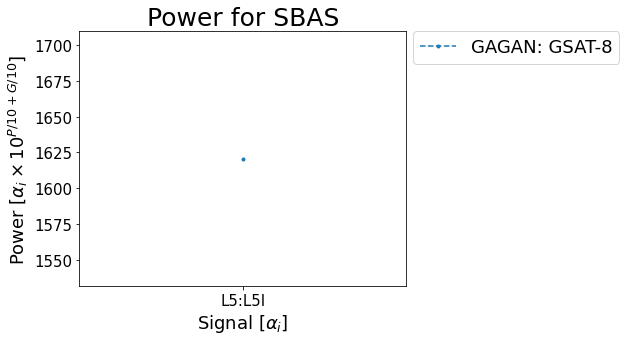

Satellites with only null alphas: ['EGNOS: Inmarsat-3 F2', 'EGNOS: Astra 5B', 'GAGAN: GSAT-15', 'SDCM: Luch-5V', 'EGNOS: Inmarsat-4 F2', 'EGNOS: SES-5', 'GAGAN: GSAT-10', 'SDCM: Luch-5B']


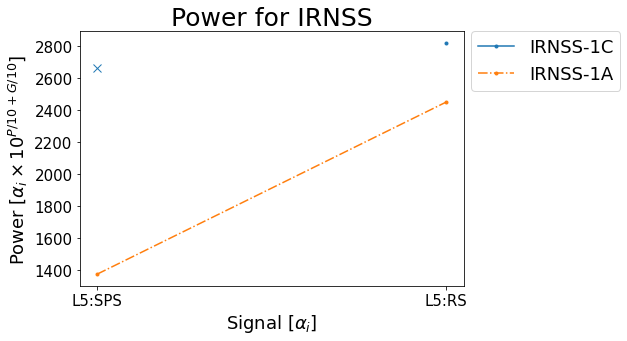

Satellites with only null alphas: ['IRNSS-1B', 'IRNSS-1I', 'IRNSS-1F']


In [11]:
cons = ["GPS","GLONASS","GALILEO","BEIDOU","SBAS","IRNSS"]
for con in cons:
    plot_power(con,log=False)


In [102]:
# --------------------- plot_1d -------------------- #
def plot_1d(con, axis="frequency"):
    ''' Plot 1d and 2d maps of the contribution of each satellite. '''

    # satellites with null alphas get removed
    nulls = []

    for i,ID in enumerate(sat.sats):
        # if alphas are null or satellite is not in cons, remove
        ind_i = sat.index_sats[i]
        ind_e = sat.n_signals[i]
        if satellites.loc[ID,"Constellation"]!=con:  continue
        if np.abs(np.linalg.norm(alphas[ind_i : ind_i+ind_e]))<1e-6:  
            nulls.append(satellites.loc[ID,'Satellite'])
            continue

        # calculating contribution
        sim_i = np.zeros_like(sat.obs)
        for j in range(ind_i, ind_i+ind_e):
            sim_i += sat.sat_beam[i] * sat.Tb_factors[j][:,None] * alphas[j]
        
        # plotting figure
        fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=False)
        for ax in axs: 
            if axis=="frequency":
                ax.plot(frequency, np.ma.mean(sat.obs_BGsub.T, axis=0), label='Observation')
                ax.plot(frequency, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=0), 
                        '--', label='Simulation')
                ax.set_xlabel('Frequency [MHz]')
            elif axis=="time": 
                ax.plot(time, np.ma.mean(sat.obs_BGsub.T, axis=1), label='Observation')
                ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1), 
                        '--', label='Simulation')
                ax.set_xlabel('Time [s]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc="upper left")
        axs[1].set_yscale("log")
        fig.suptitle(f"Satellite {satellites.loc[ID,'Satellite']}")
        fig.tight_layout()
        plt.show()
        
    print(f"Satellites with only null alphas: {nulls}")
    

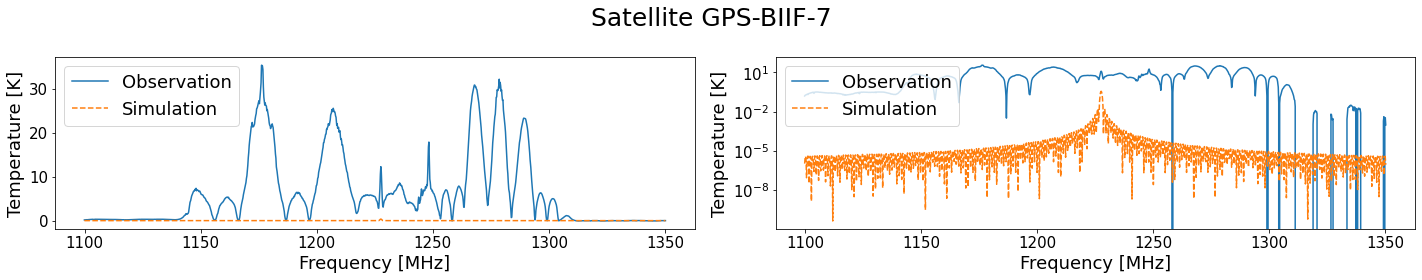

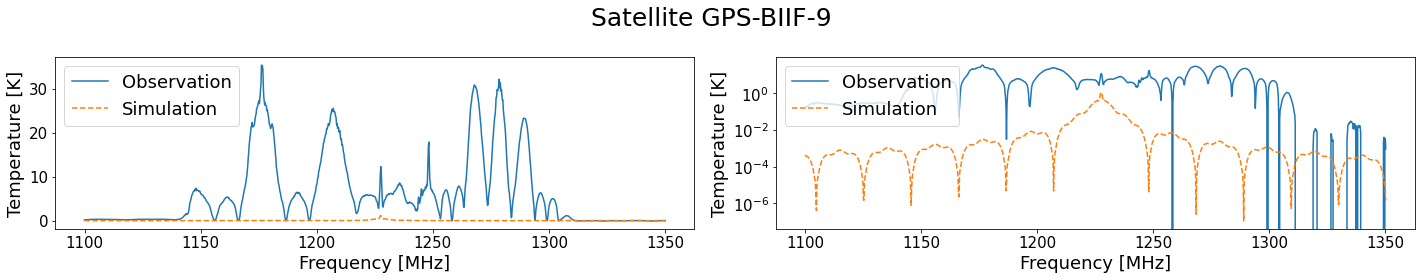

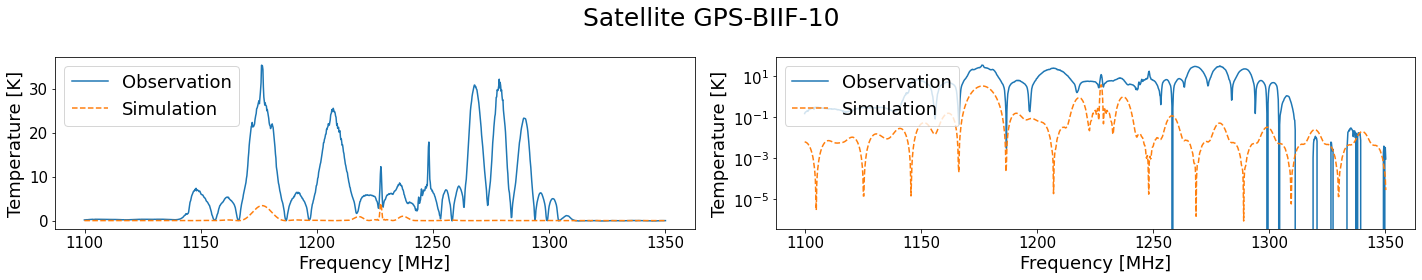

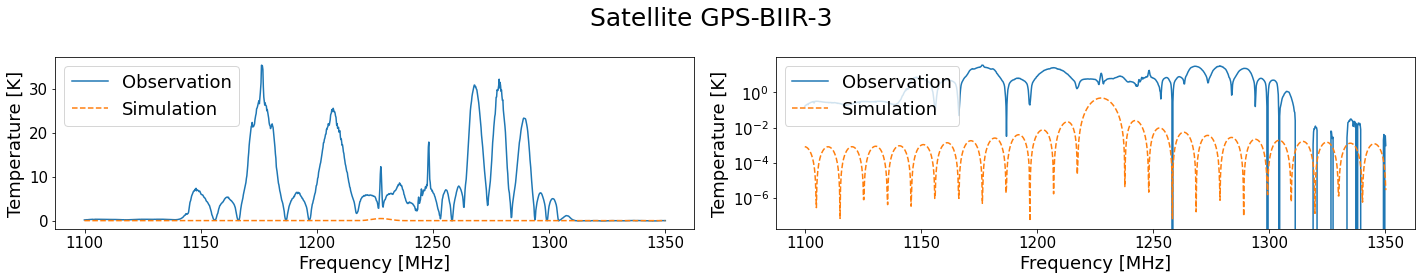

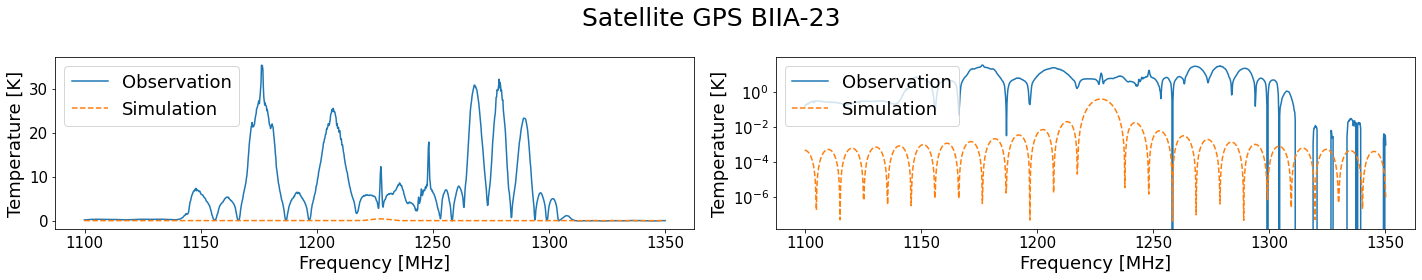

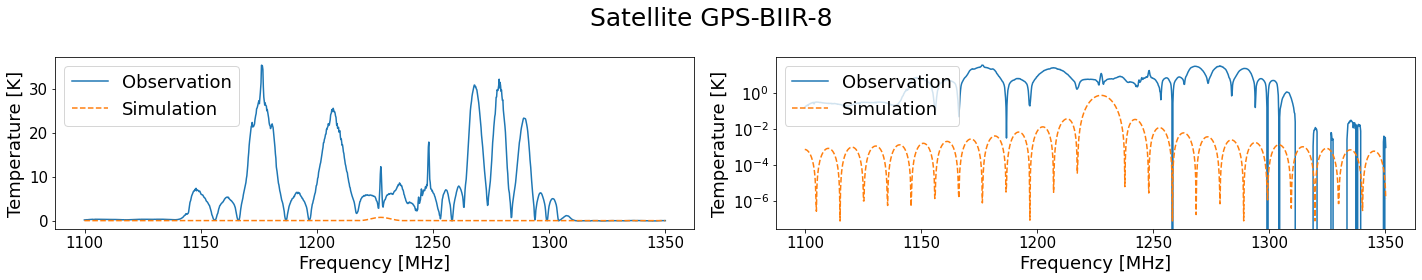

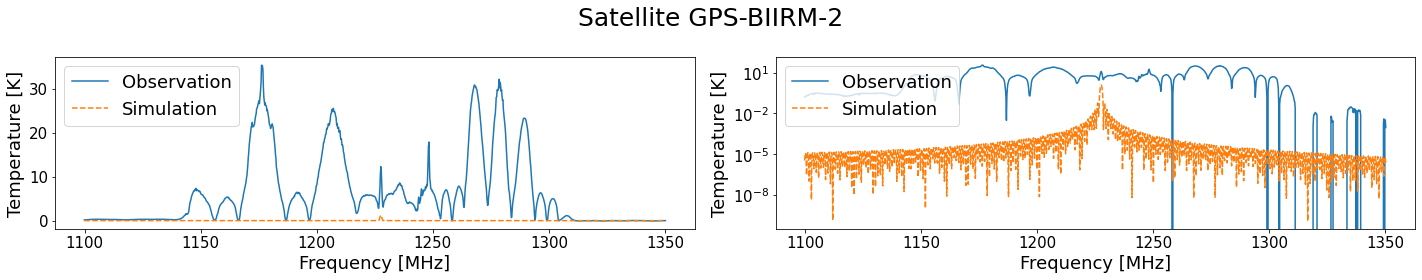

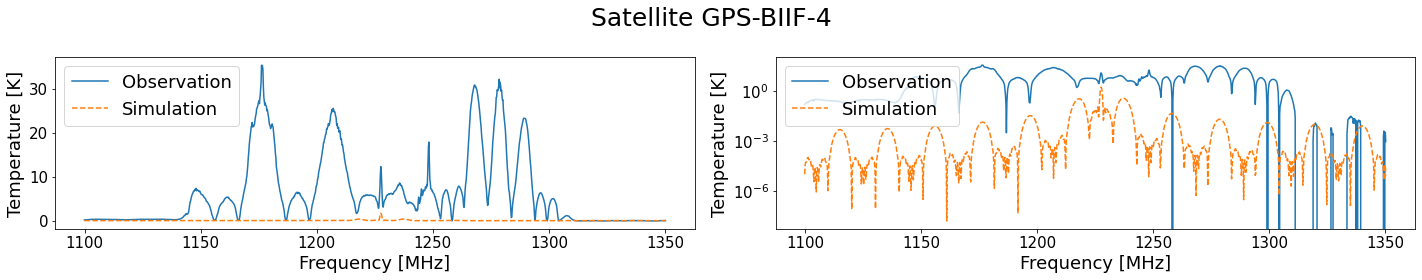

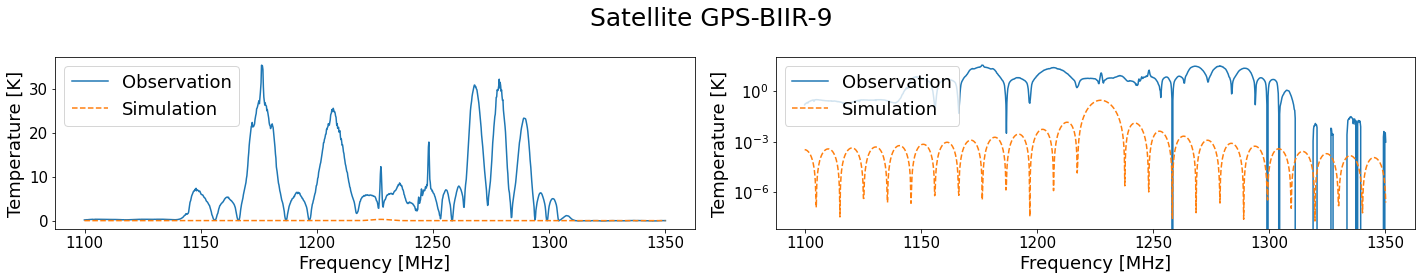

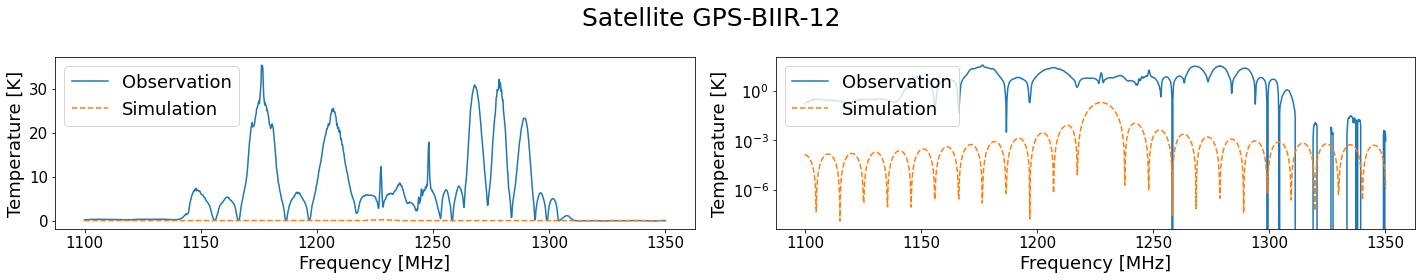

Satellites with only null alphas: ['GPS-BIIF-12', 'GPS-BIIF-8', 'GPS-BIIR-6', 'GPS-BIIRM-6', 'GPS-BIIR-10']


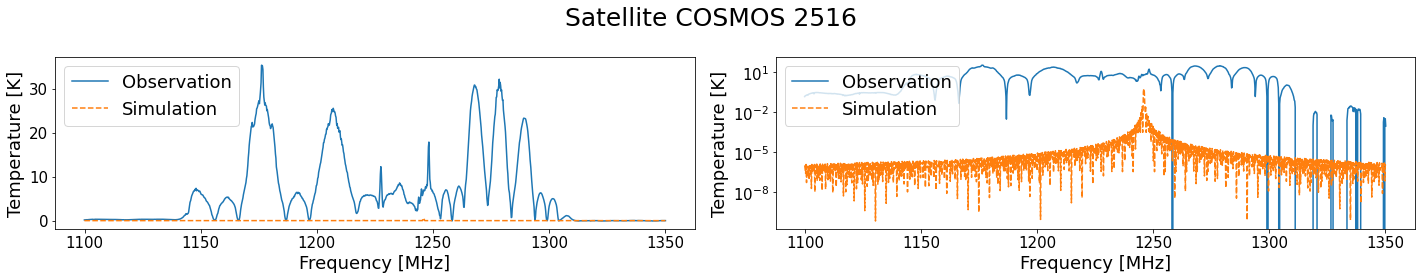

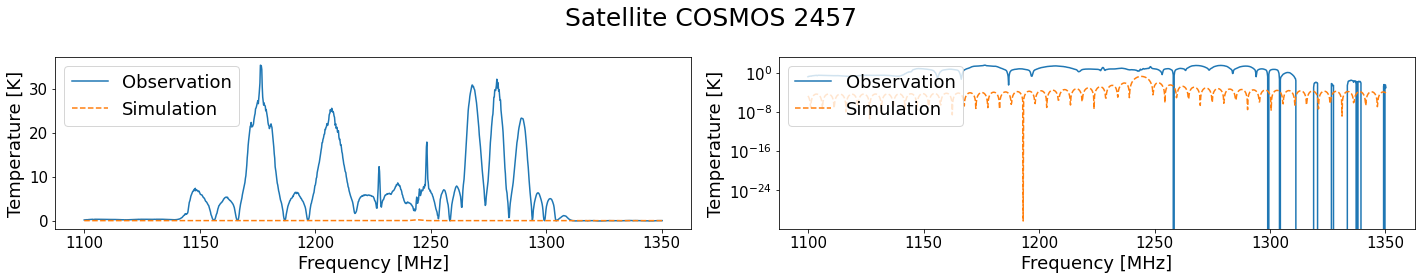

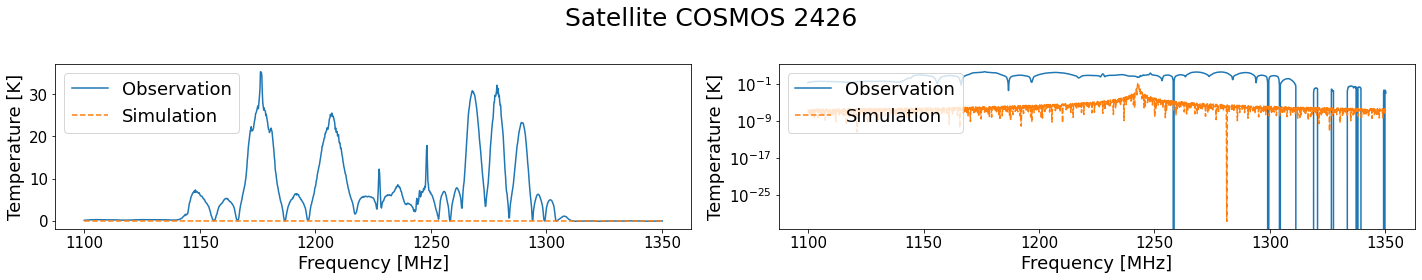

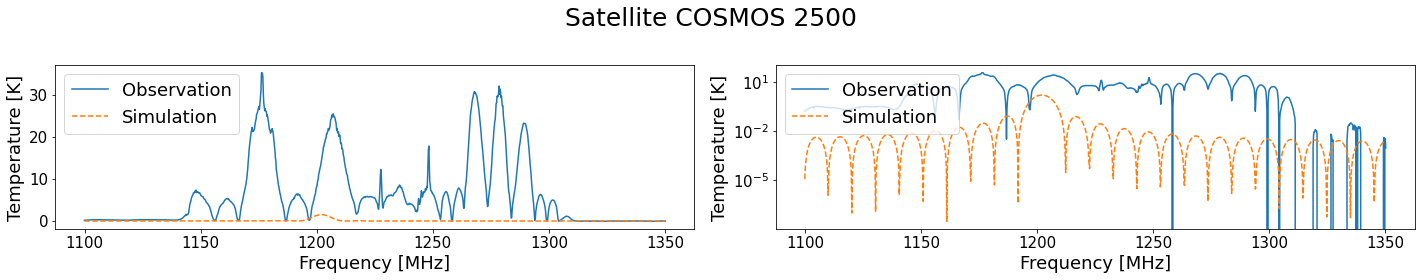

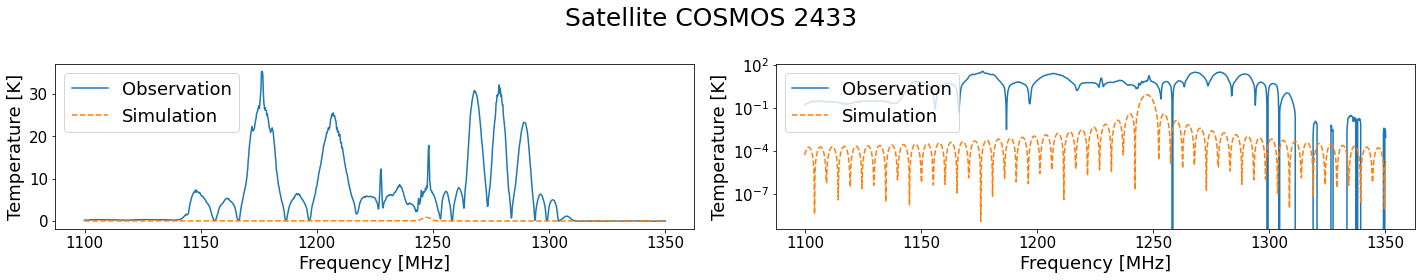

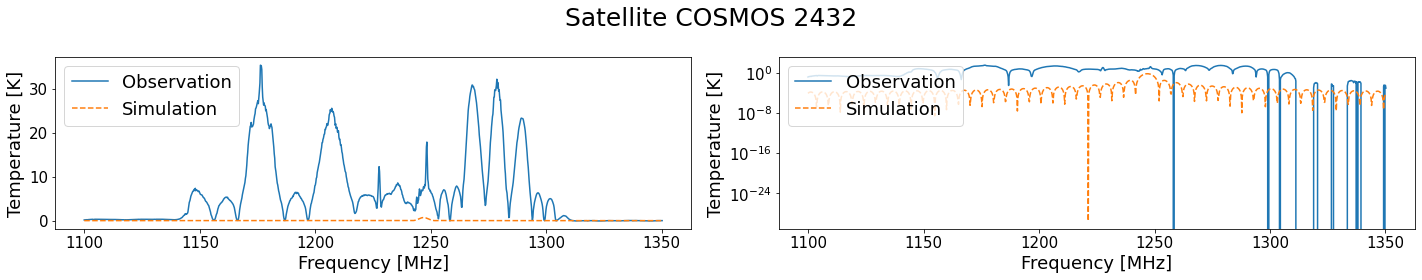

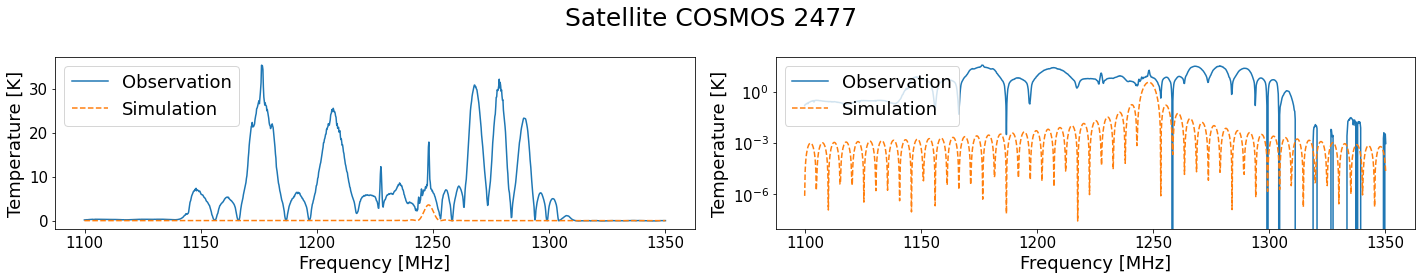

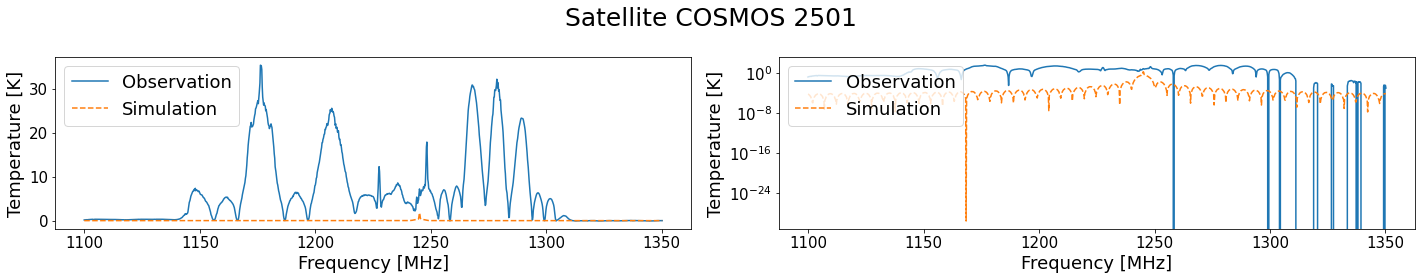

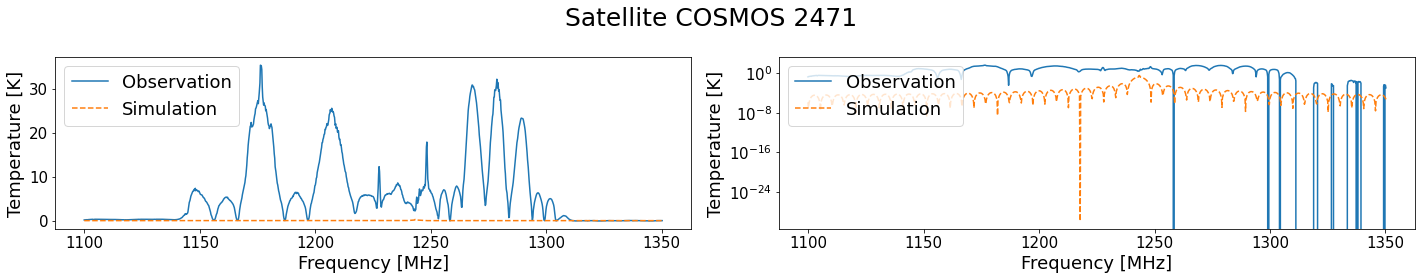

Satellites with only null alphas: ['COSMOS 2492', 'COSMOS 2475', 'COSMOS 2464', 'COSMOS 2456']


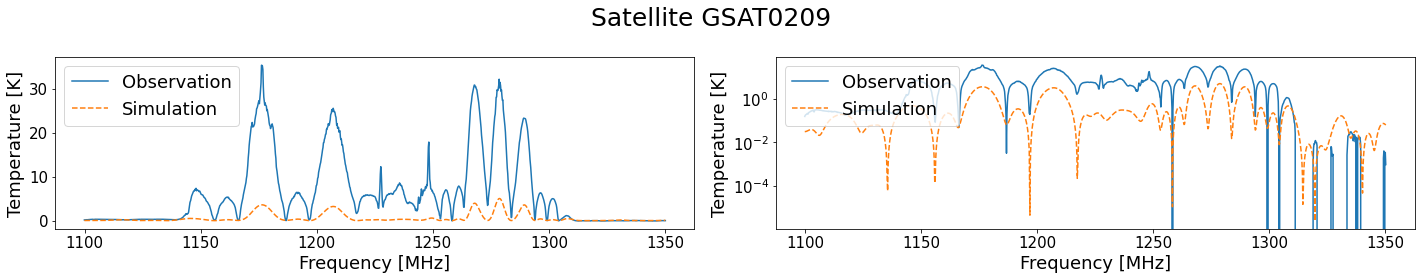

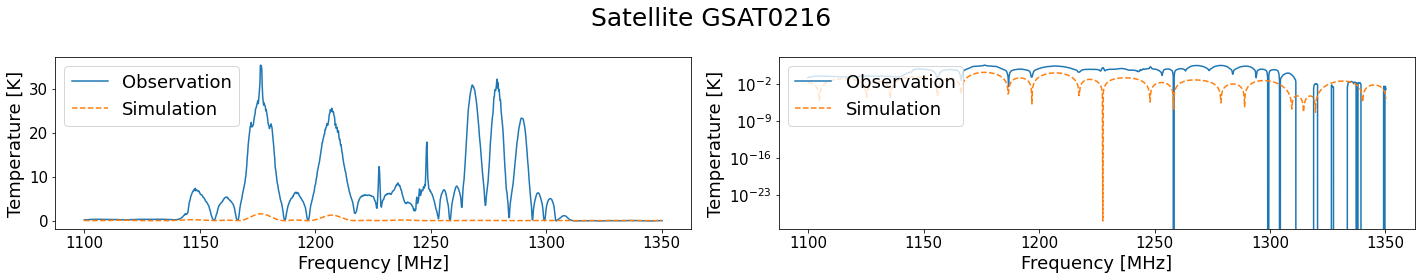

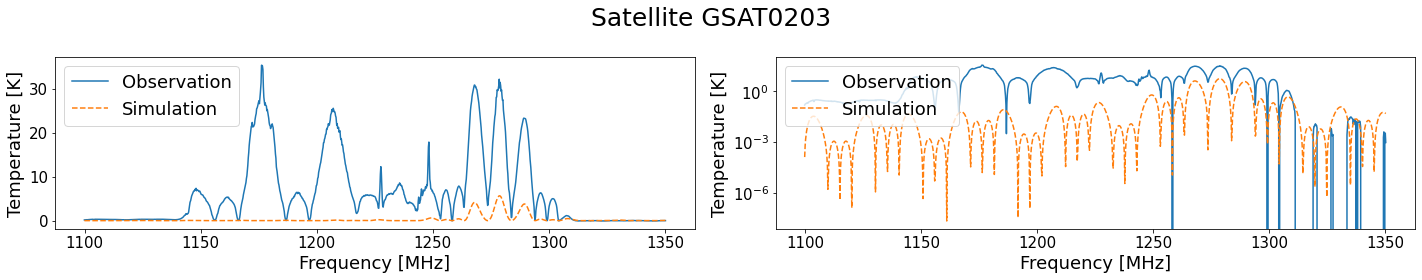

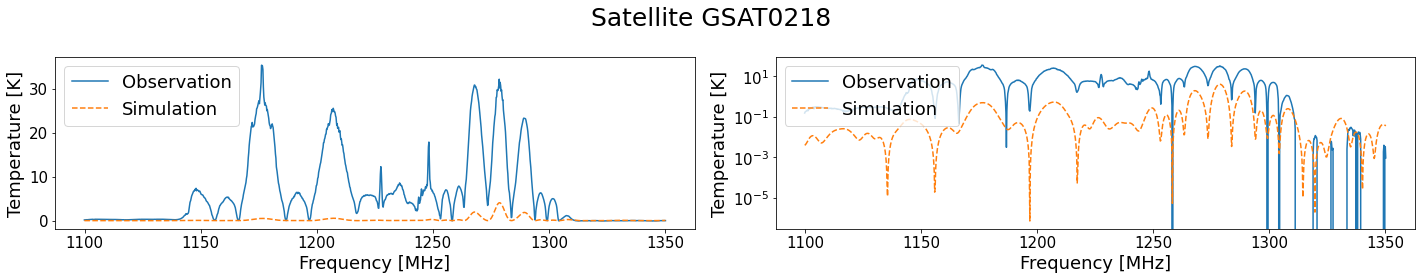

Satellites with only null alphas: ['GSAT0201', 'GSAT0205', 'GSAT0210', 'GSAT0222', 'GSAT0213', 'GSAT0214', 'GSAT0102', 'GSAT0212', 'GSAT0101']


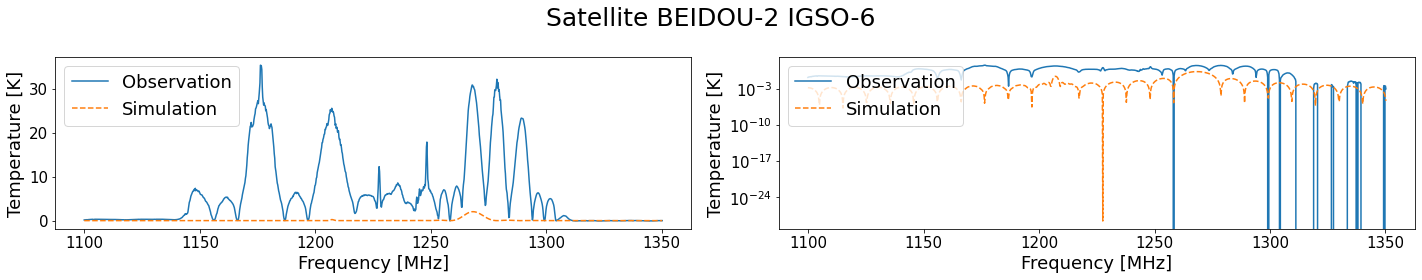

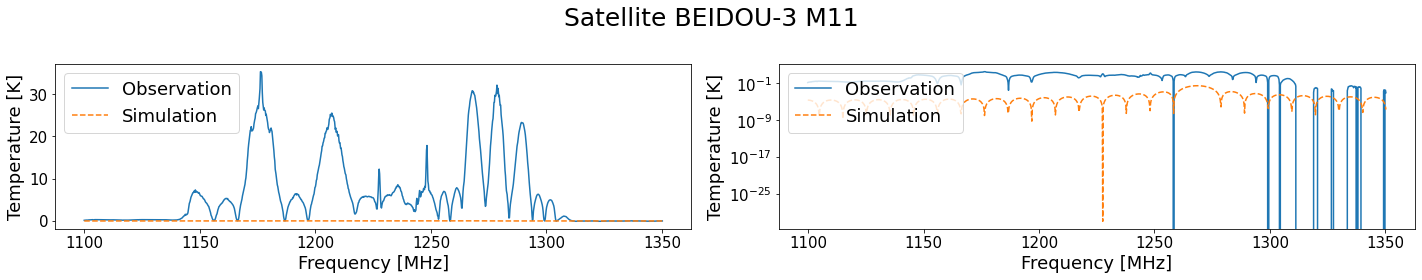

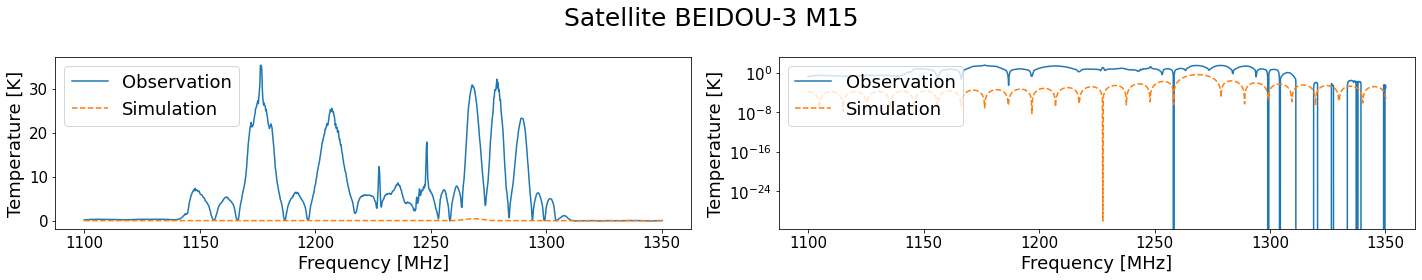

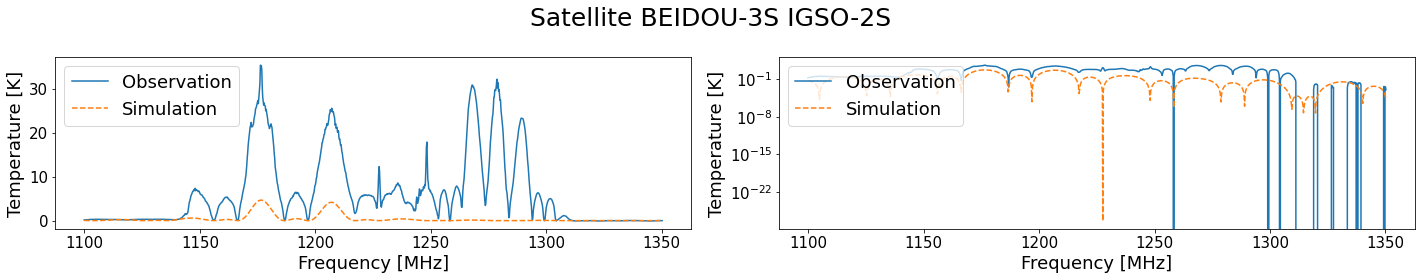

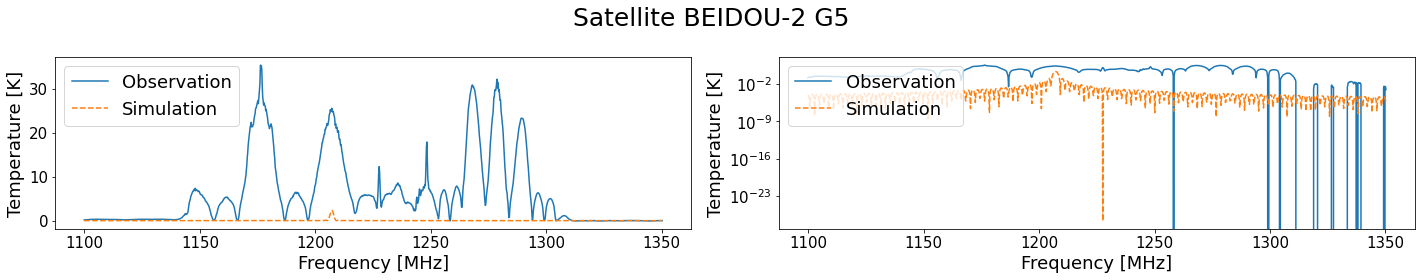

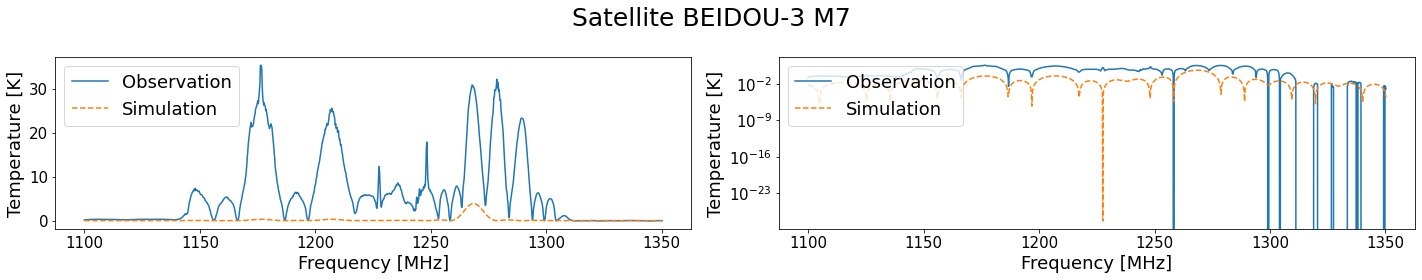

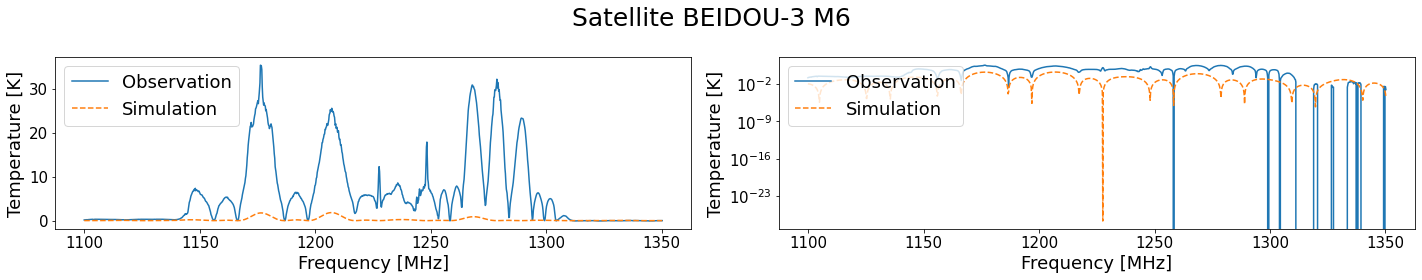

Satellites with only null alphas: ['BEIDOU-3S IGSO-1S', 'BEIDOU-2 IGSO-5', 'BEIDOU-2 M6', 'BEIDOU-2 IGSO-3', 'BEIDOU-2 M4', 'BEIDOU-3 M17', 'BEIDOU-3 M5', 'BEIDOU-3 M1', 'BEIDOU-2 G6', 'BEIDOU-2 G3', 'BEIDOU-3 M8']


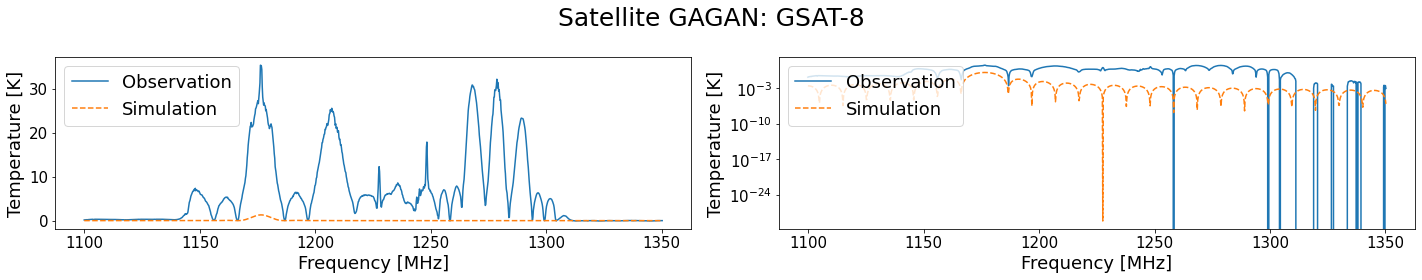

Satellites with only null alphas: ['EGNOS: Inmarsat-3 F2', 'EGNOS: Astra 5B', 'GAGAN: GSAT-15', 'SDCM: Luch-5V', 'EGNOS: Inmarsat-4 F2', 'EGNOS: SES-5', 'GAGAN: GSAT-10', 'SDCM: Luch-5B']


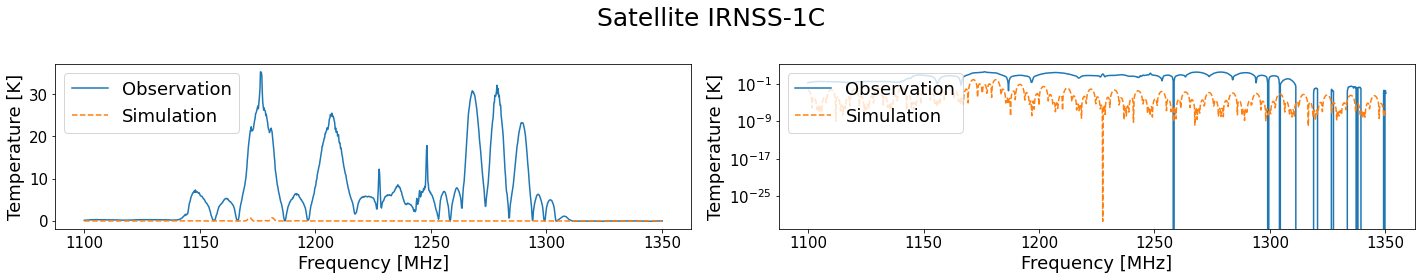

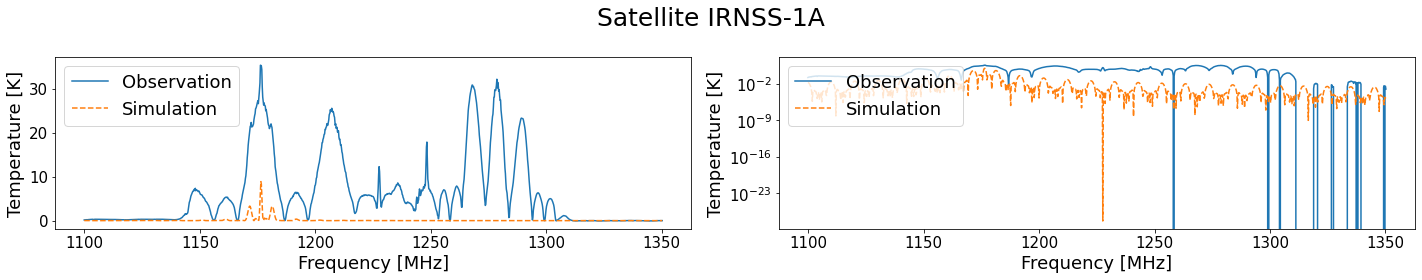

Satellites with only null alphas: ['IRNSS-1B', 'IRNSS-1I', 'IRNSS-1F']


In [103]:
cons = ["GPS","GLONASS","GALILEO","BEIDOU","SBAS","IRNSS"]
for con in cons:
    plot_1d(con, axis="frequency")

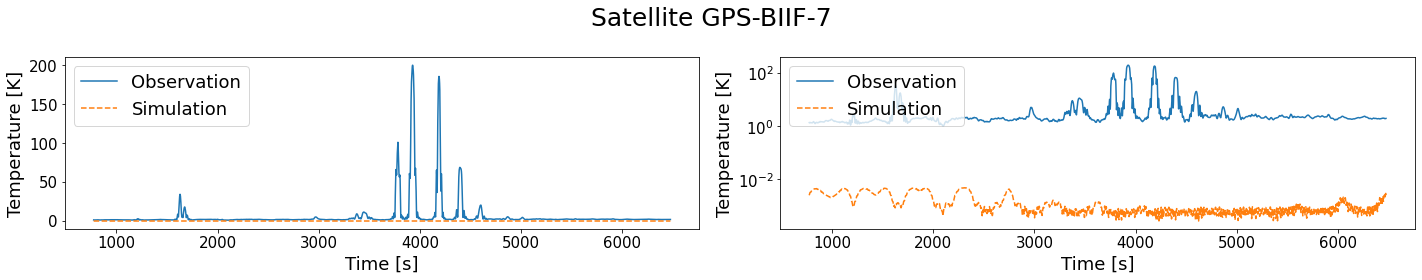

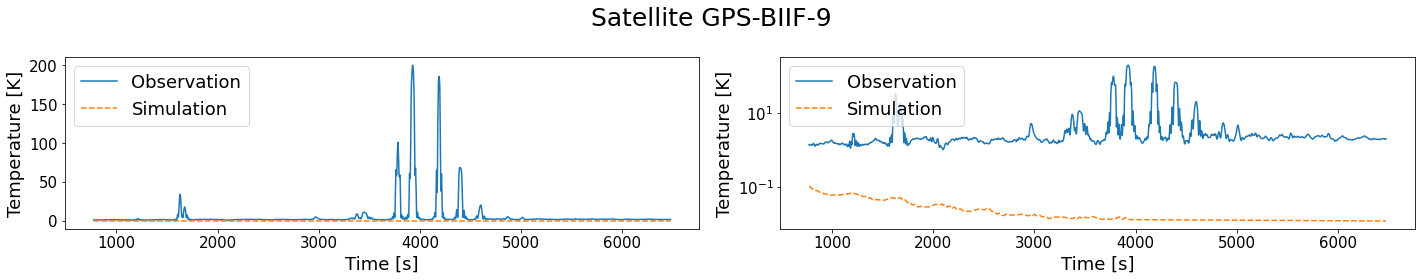

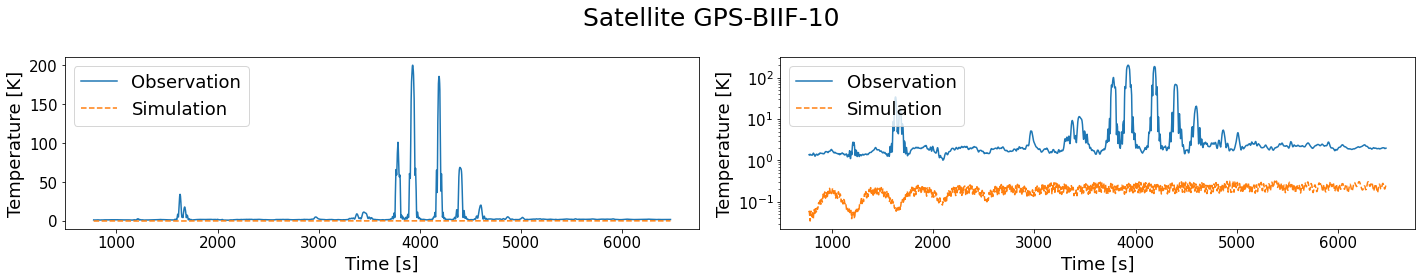

<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),
<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),


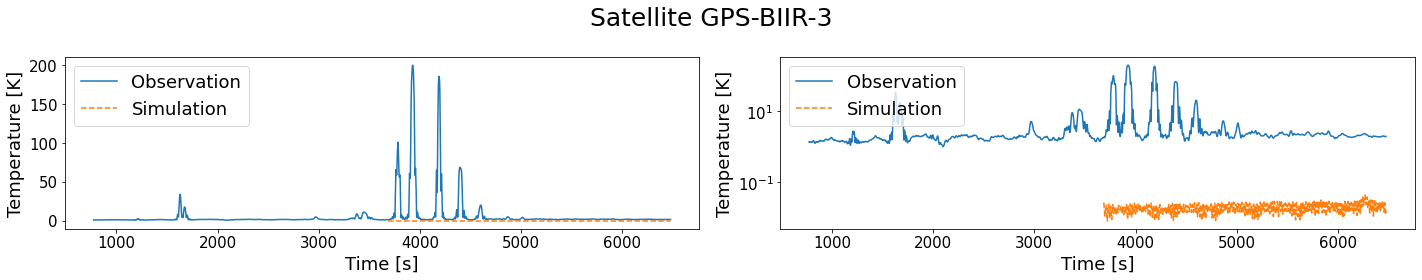

<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),
<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),


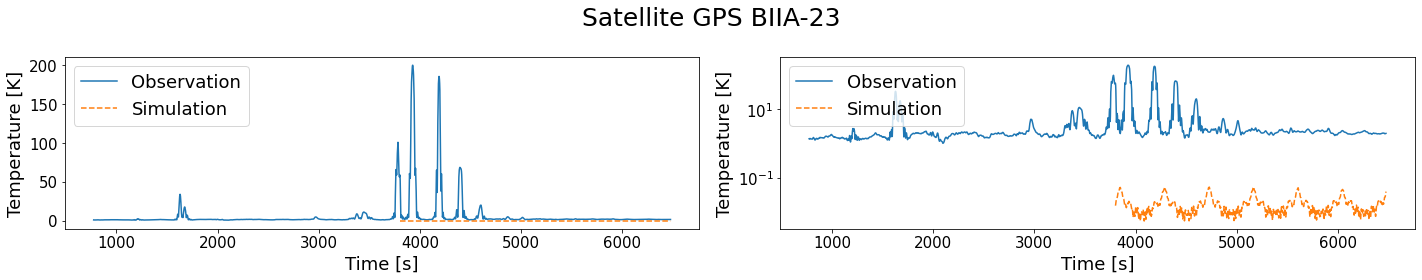

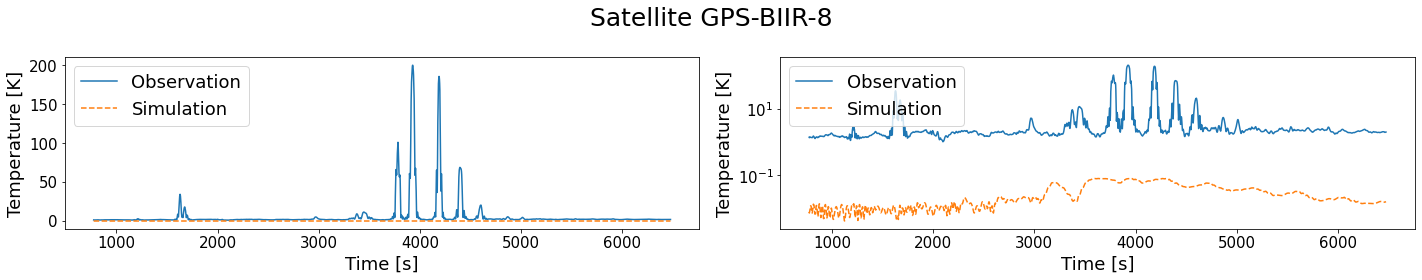

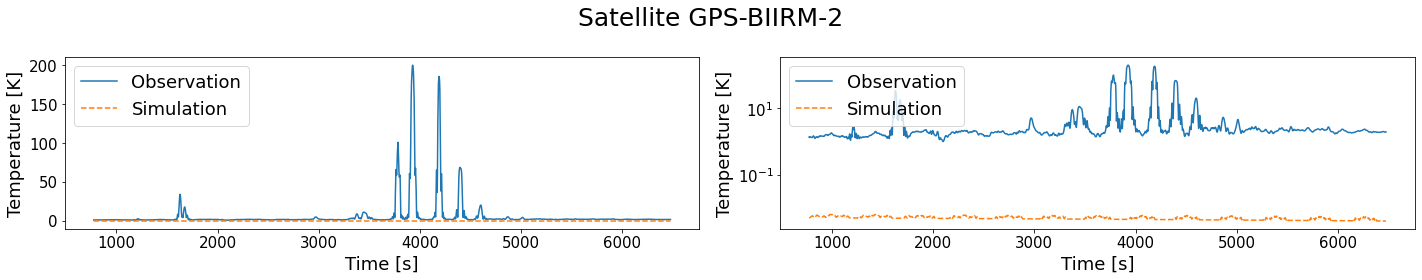

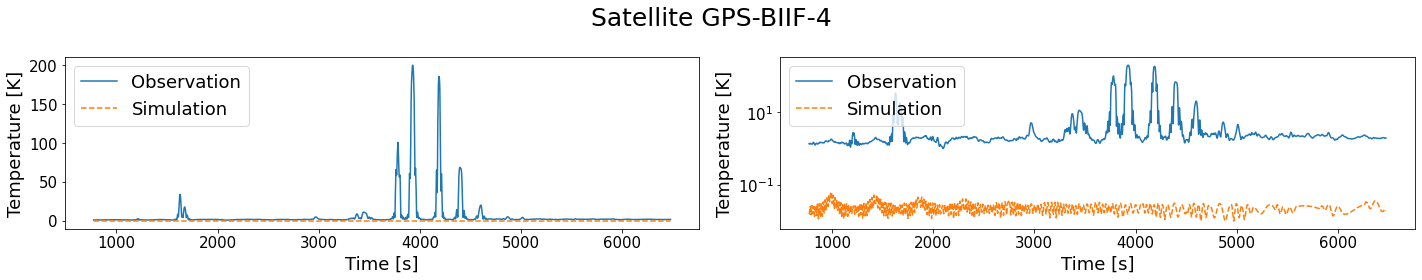

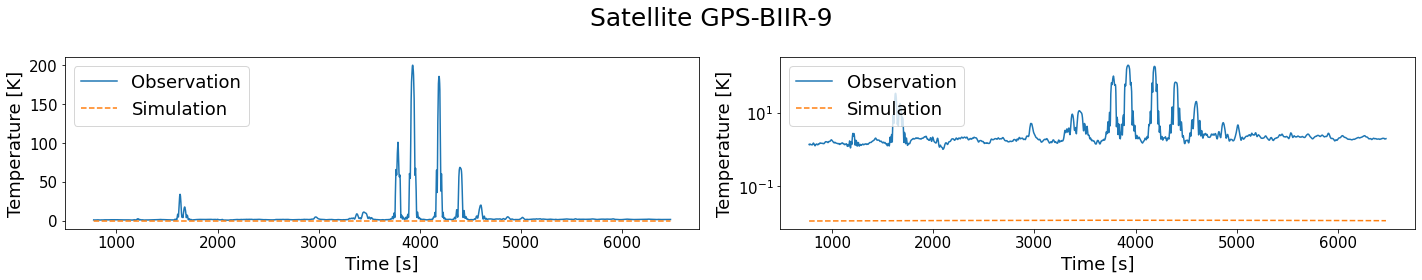

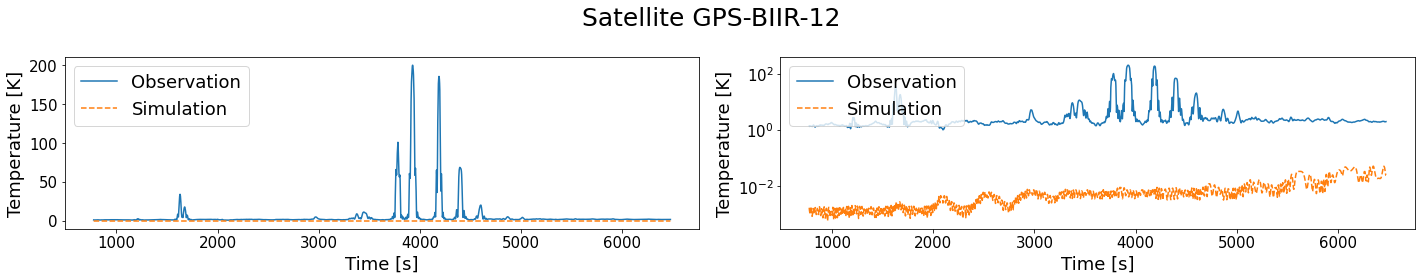

Satellites with only null alphas: ['GPS-BIIF-12', 'GPS-BIIF-8', 'GPS-BIIR-6', 'GPS-BIIRM-6', 'GPS-BIIR-10']


<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),
<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),


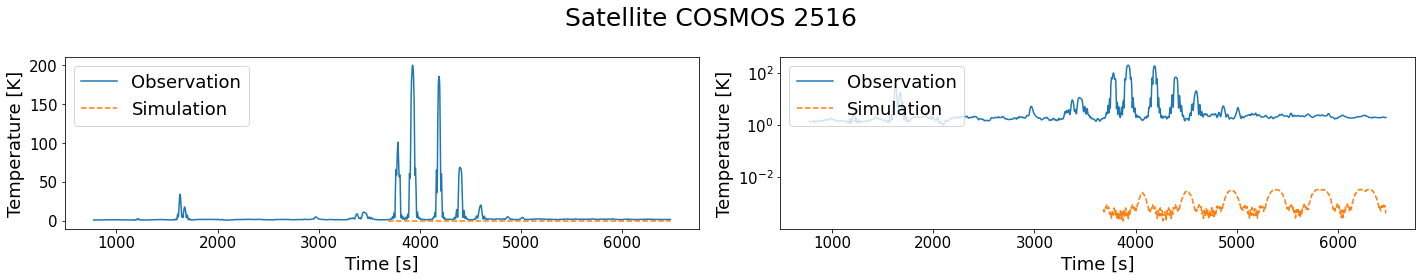

<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),
<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),


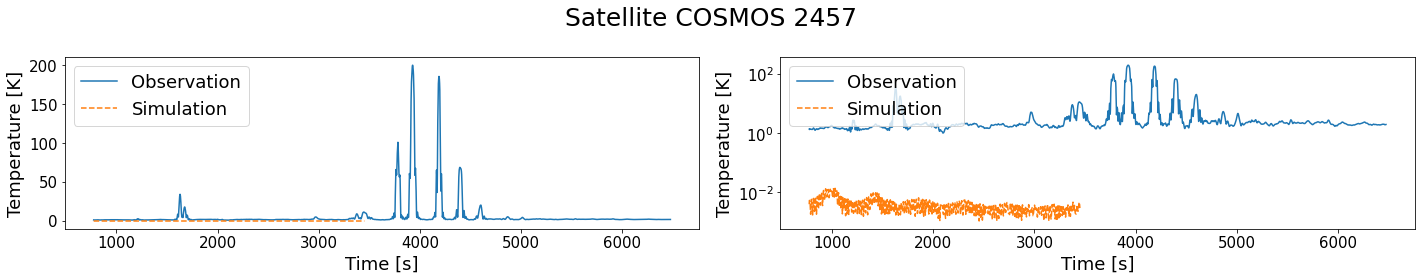

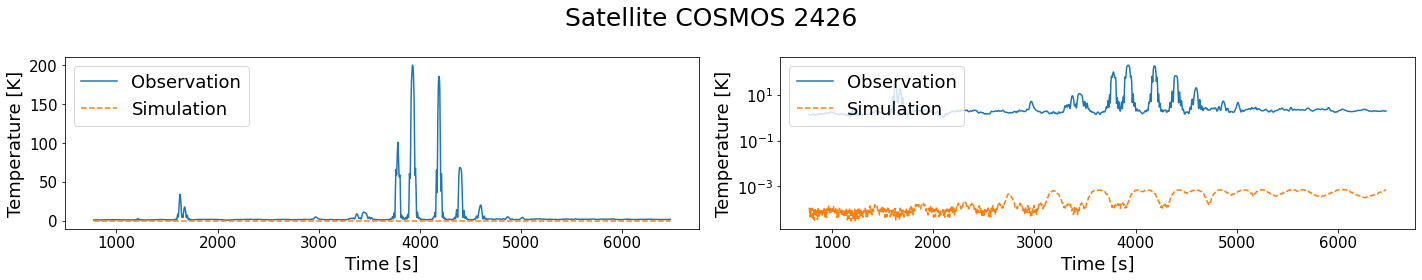

<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),
<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),


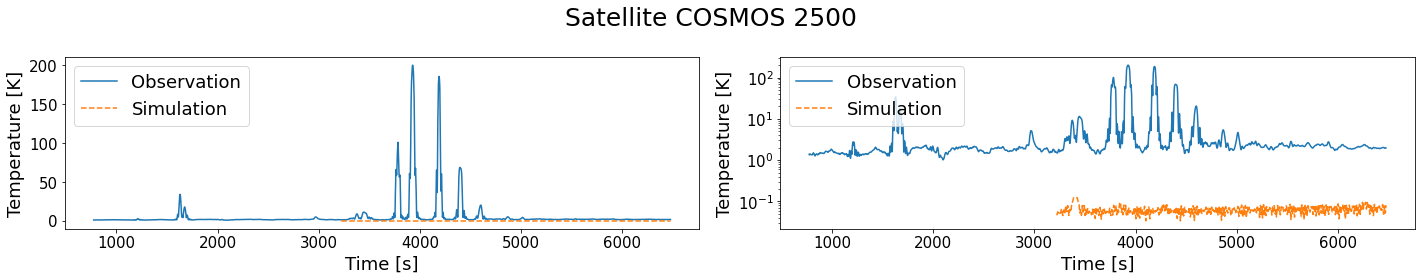

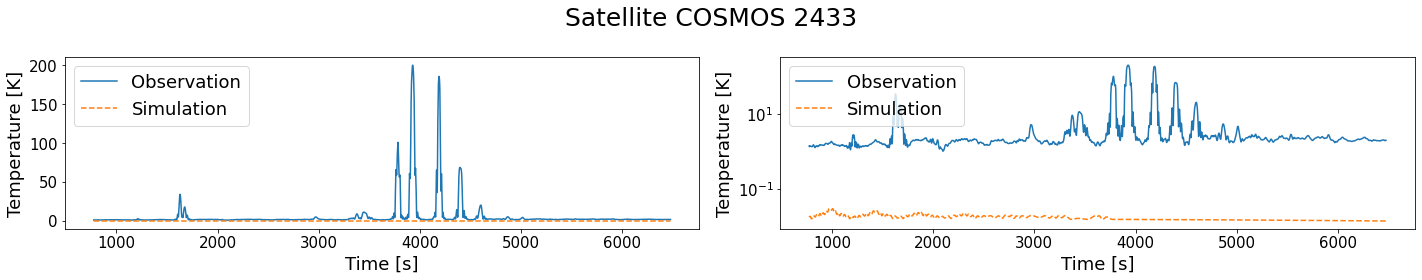

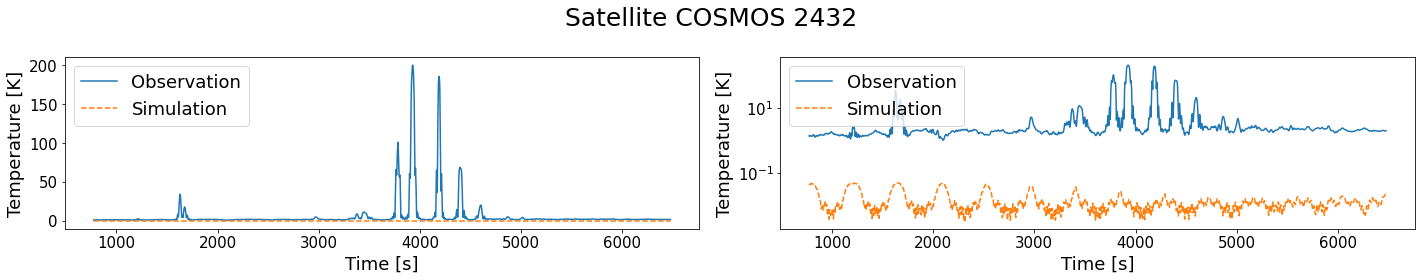

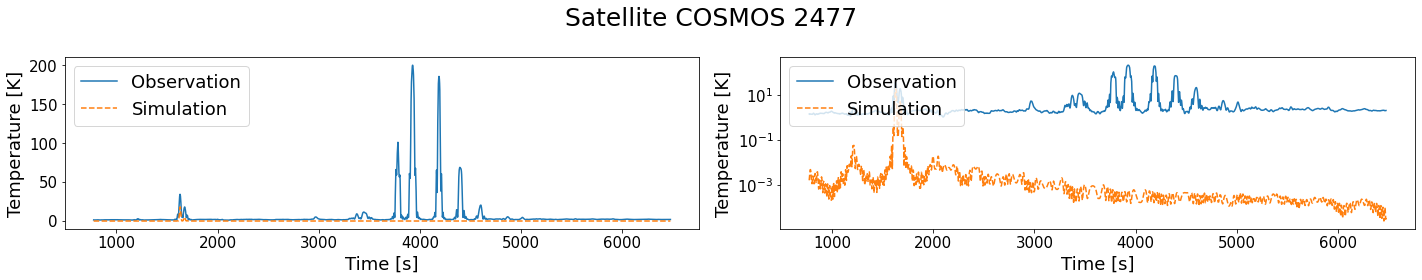

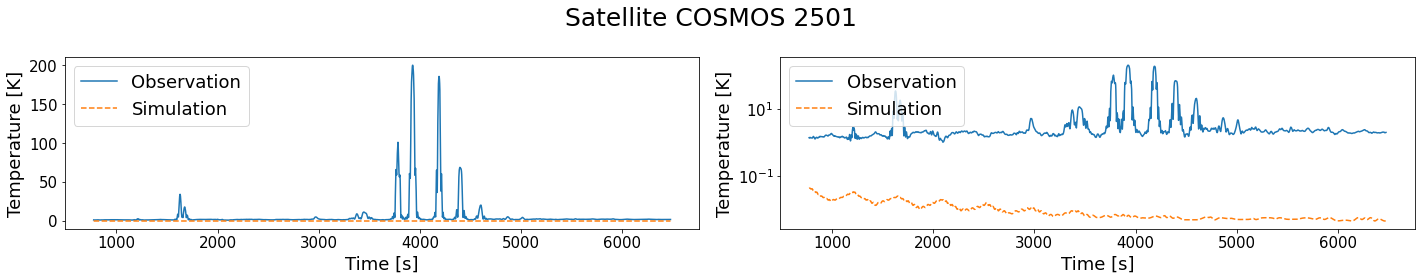

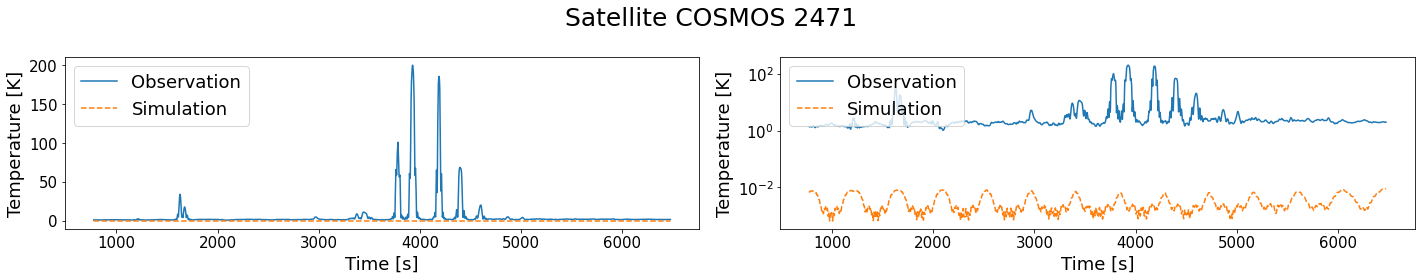

Satellites with only null alphas: ['COSMOS 2492', 'COSMOS 2475', 'COSMOS 2464', 'COSMOS 2456']


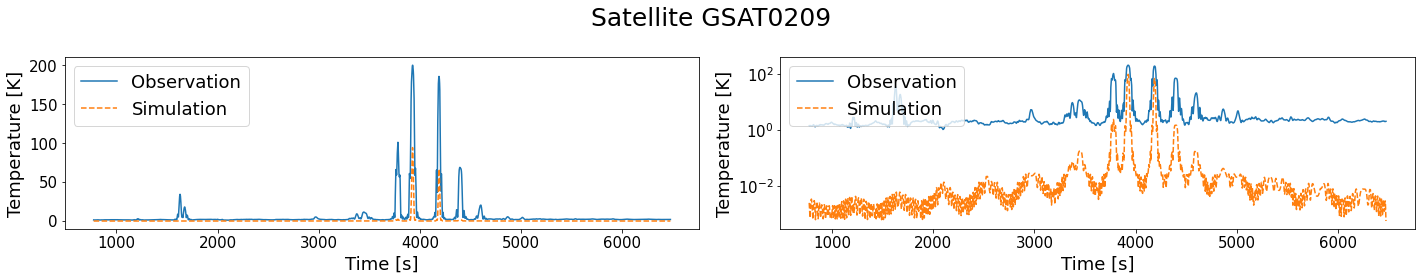

<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),
<ipython-input-102-835c07b7f455>:32: RuntimeWarning: Mean of empty slice
  ax.plot(time, np.nanmean(np.where(sim_i.T>0,sim_i.T,np.nan), axis=1),


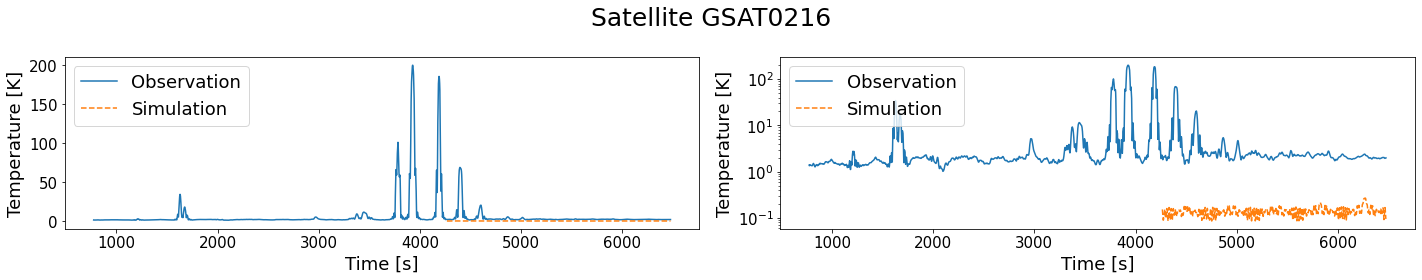

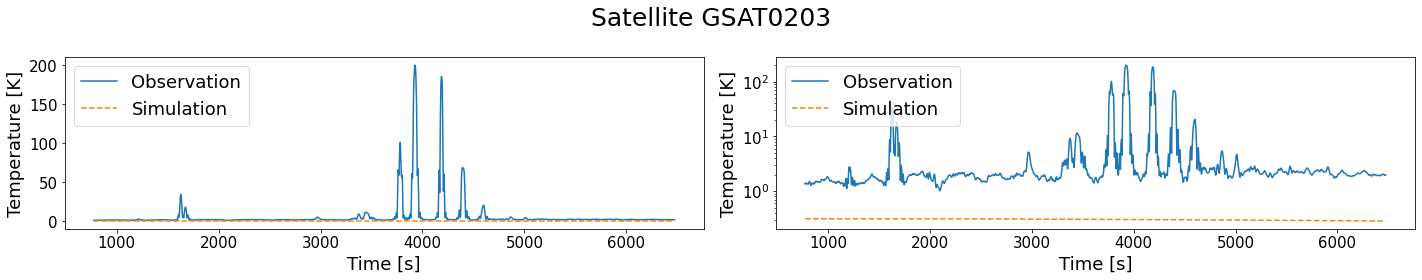

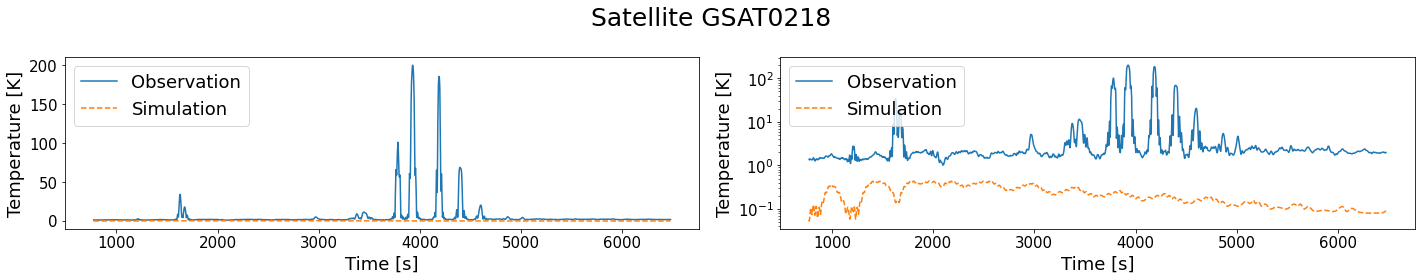

Satellites with only null alphas: ['GSAT0201', 'GSAT0205', 'GSAT0210', 'GSAT0222', 'GSAT0213', 'GSAT0214', 'GSAT0102', 'GSAT0212', 'GSAT0101']


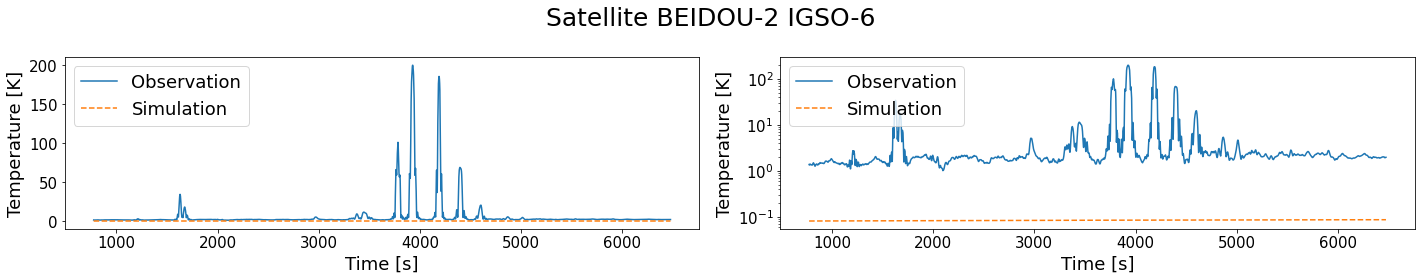

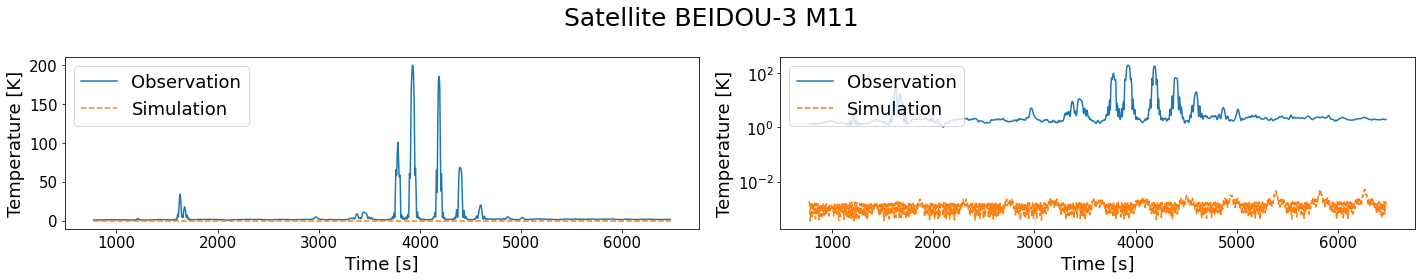

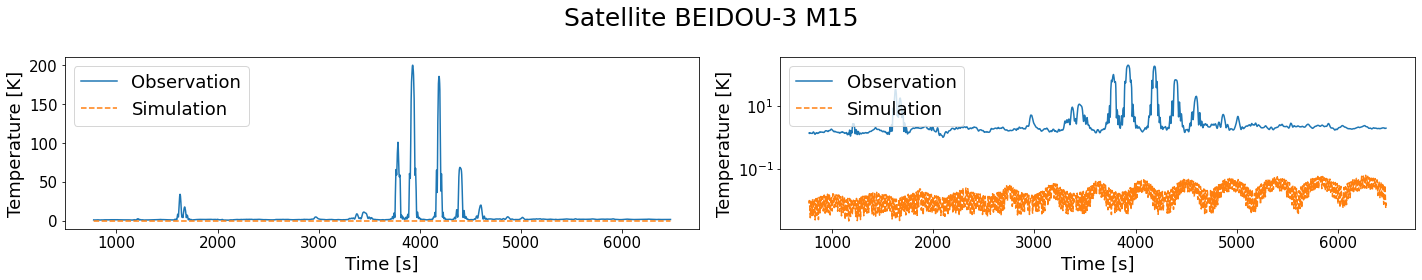

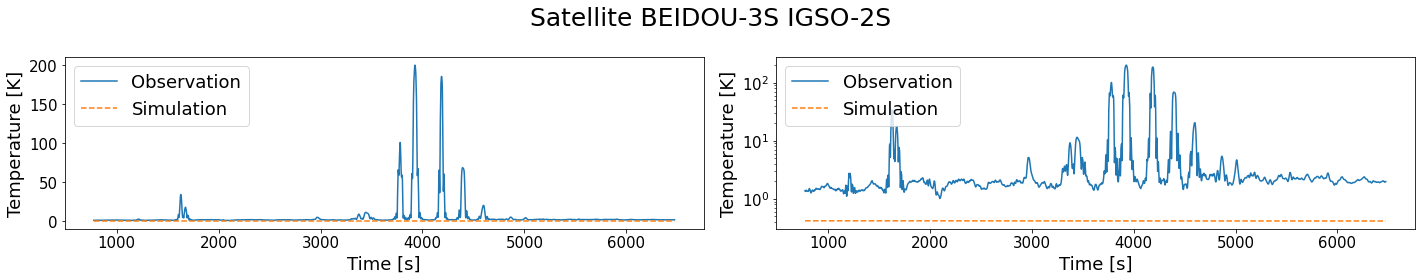

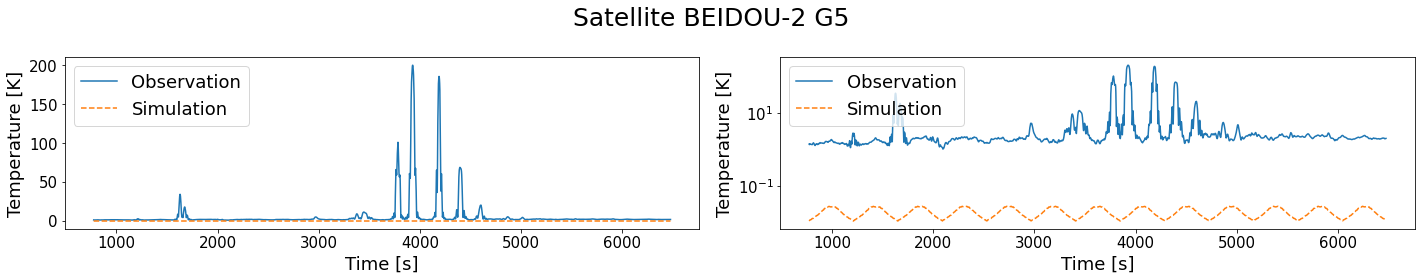

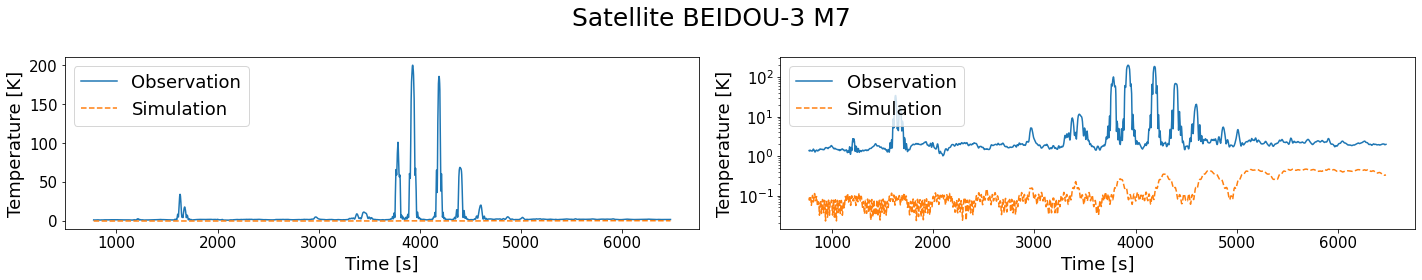

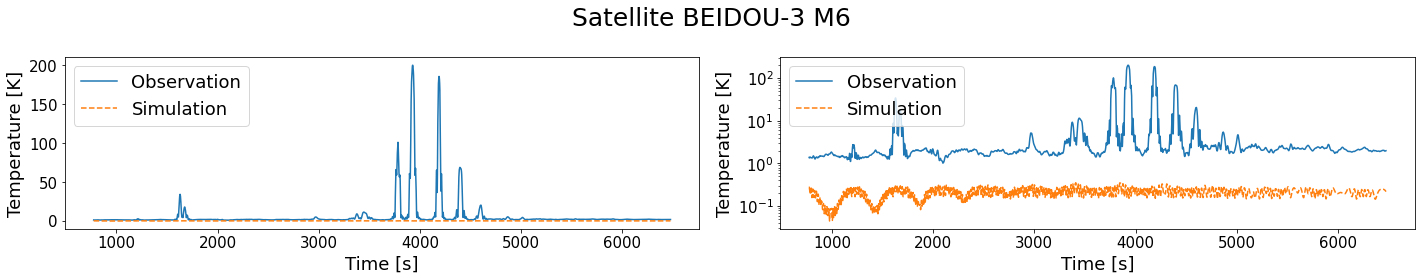

Satellites with only null alphas: ['BEIDOU-3S IGSO-1S', 'BEIDOU-2 IGSO-5', 'BEIDOU-2 M6', 'BEIDOU-2 IGSO-3', 'BEIDOU-2 M4', 'BEIDOU-3 M17', 'BEIDOU-3 M5', 'BEIDOU-3 M1', 'BEIDOU-2 G6', 'BEIDOU-2 G3', 'BEIDOU-3 M8']


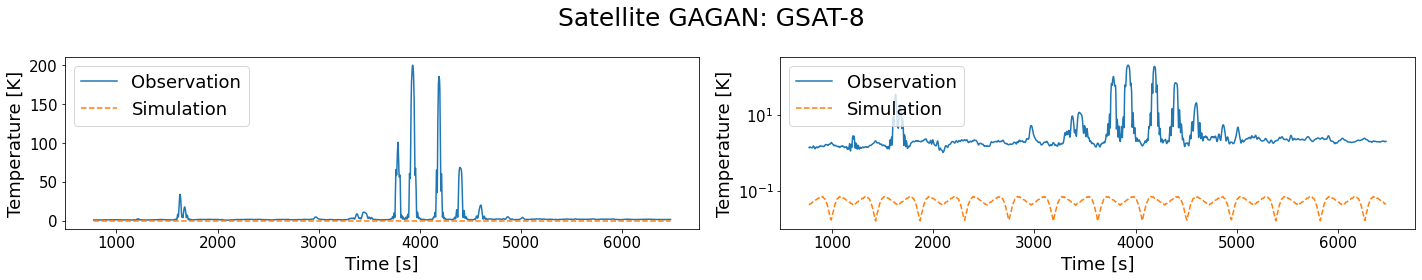

Satellites with only null alphas: ['EGNOS: Inmarsat-3 F2', 'EGNOS: Astra 5B', 'GAGAN: GSAT-15', 'SDCM: Luch-5V', 'EGNOS: Inmarsat-4 F2', 'EGNOS: SES-5', 'GAGAN: GSAT-10', 'SDCM: Luch-5B']


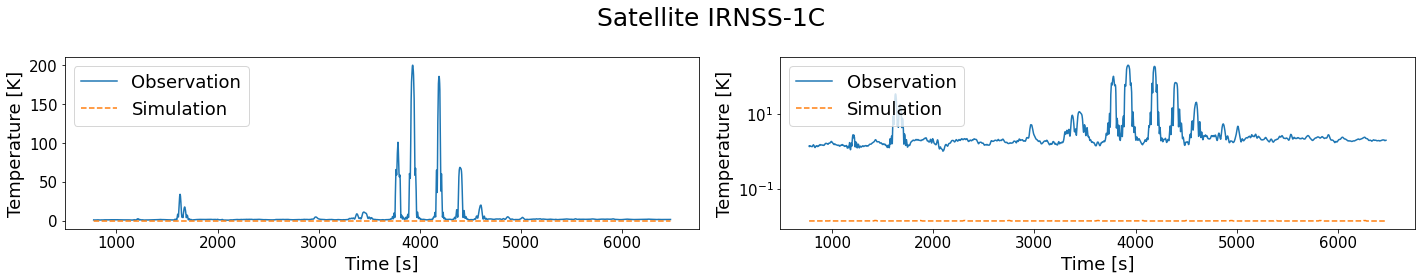

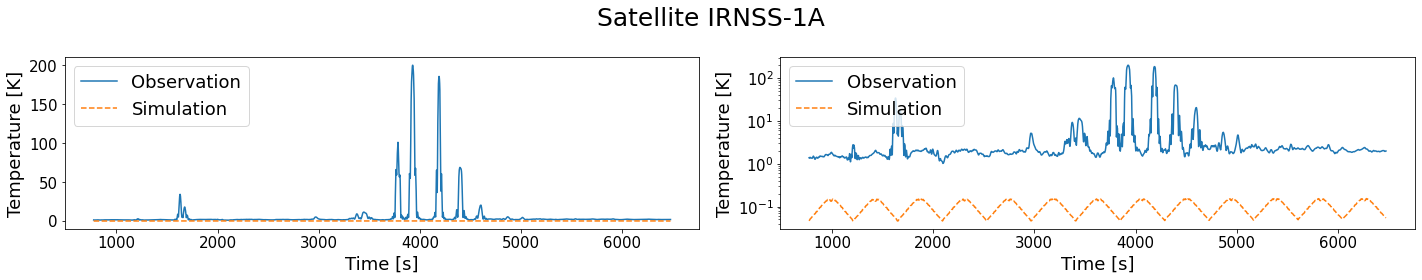

Satellites with only null alphas: ['IRNSS-1B', 'IRNSS-1I', 'IRNSS-1F']


In [104]:
for con in cons:
    plot_1d(con, axis="time")

In [ ]:
# --------------- plot_contributions --------------- #
def plot_contributions(con, log=False):
    ''' Plot simulated signal of each satellite integrated in 
    time and frequency for a given constellation. '''

    # creating figure
    fig, ax = plt.subplots(figsize=(9, 5))
    linestyles = ["-", "--", "-.", ":"]
    nulls = []

    for i,ID in enumerate(sat.sats):
        # getting values
        if satellites.loc[ID,"Constellation"]!=con:  continue
        ys = alphas[sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]
        xs = sat.catalog.loc[sat.catalog["NORAD ID"]==ID,"Signal"]
        name = satellites.loc[ID,"Satellite"]

        # if satellite has only null alphas, remove
        if np.abs(np.linalg.norm(ys))<1e-6:  
            nulls.append(name)
            continue

        #plotting the rest
        ys_plot = np.where(ys>0,ys,np.nan)
        if log:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=name)
        else:  ax.plot(xs, ys_plot, linestyle=linestyles[i%4], marker=".", label=f"{name}")

        # plotting zero values
        idx0 = np.where(np.abs(ys)<1e-6)[0]
        if len(idx0):
            ax.plot(np.asarray(xs)[idx0], np.full(len(idx0), ax.get_ylim()[0]), "x",
                    color=ax.lines[-1].get_color(), ms=8)

    # showing figure
    if log:  
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_ylabel('Amplitude')
    ax.set_xlabel(r'Signal $[\alpha_{i}]$')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.set_title(f"Alphas for {con}")
    fig.tight_layout()
    plt.show()
    print(f"Satellites with only null alphas: {nulls}")
    